In [2]:
import pandas as pd
df = pd.read_csv("shipments.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5893 entries, 0 to 5892
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   shipment_id            5893 non-null   object 
 1   timestamp              5893 non-null   object 
 2   severity               5893 non-null   object 
 3   thread                 5893 non-null   object 
 4   source                 5893 non-null   object 
 5   event                  5893 non-null   object 
 6   station                5750 non-null   object 
 7   box_barcode            5893 non-null   object 
 8   articles               5750 non-null   float64
 9   exp_weight_kg          5750 non-null   float64
 10  act_weight_kg          5750 non-null   float64
 11  tare_weight_kg         5750 non-null   float64
 12  product_weight_kg      5750 non-null   float64
 13  abs_weight_diff        5750 non-null   float64
 14  print_quality_pct      4425 non-null   float64
 15  line

In [4]:
df.shape

(5893, 23)

# Analyse: Auffälligkeiten und Performance pro Packstation

In [5]:
df = df.copy()

# Alle Zeilen löschen, in denen die Spalte station leer ist (NaN).
df = df.dropna(subset=["station"])

# Missing Values fixen
df["print_quality_pct"] = df["print_quality_pct"].fillna(df["print_quality_pct"].median())
df["line_speed_mps"] = df["line_speed_mps"].fillna(df["line_speed_mps"].median())

# Gruppierung nach Station
station_kpis = df.groupby("station").agg(
    total_shipments=("shipment_id", "count"),
    kickouts=("is_kot", "sum"),
    kickout_rate=("is_kot", "mean"),
    avg_weight_diff=("abs_weight_diff", "mean"),
    avg_print_quality=("print_quality_pct", "mean"),
    avg_speed=("line_speed_mps", "mean")
).reset_index()

# sortieren nach Problem
station_kpis = station_kpis.sort_values(by="kickout_rate", ascending=False)
station_kpis


,station,total_shipments,kickouts,kickout_rate,avg_weight_diff,avg_print_quality,avg_speed
10,Station-11,494,144,0.291498,0.055023,93.952897,1.610628
11,Station-12,475,125,0.263158,0.047274,94.125947,1.602863
6,Station-07,488,124,0.254098,0.047687,94.033786,1.617725
7,Station-08,508,126,0.248031,0.046591,94.020842,1.591654
1,Station-02,489,114,0.233129,0.047338,93.993341,1.579714
3,Station-04,469,106,0.226013,0.045217,94.128518,1.627974
9,Station-10,490,109,0.222449,0.043076,94.031875,1.617918
5,Station-06,448,98,0.218750,0.042270,93.860003,1.567098
0,Station-01,459,94,0.204793,0.042713,94.057067,1.582505
4,Station-05,484,99,0.204545,0.045153,93.946785,1.645847


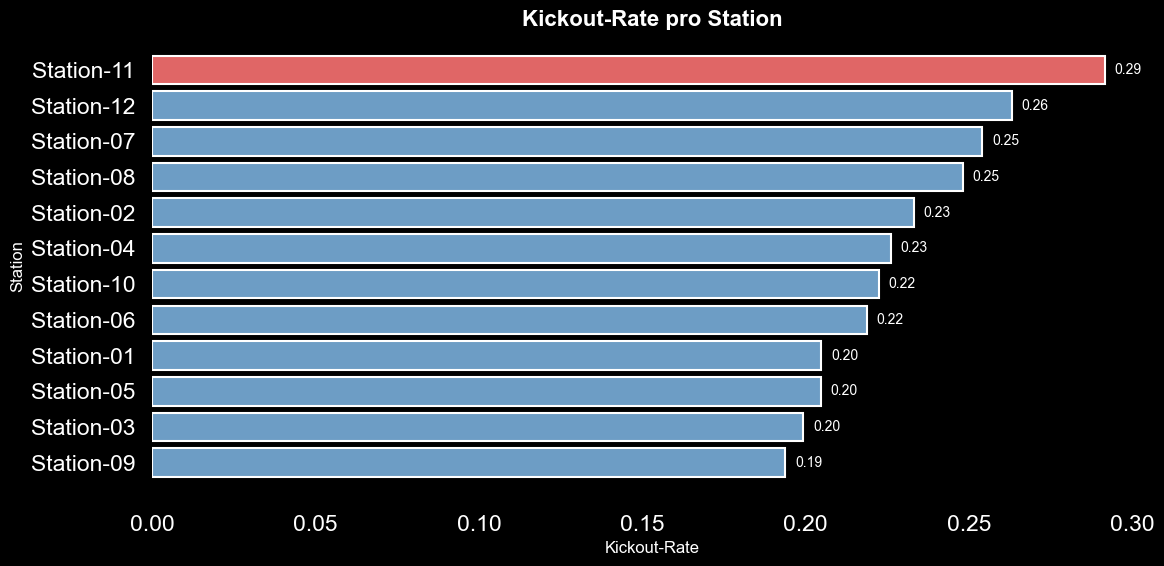

In [12]:
import matplotlib.pyplot as plt

# Sortieren
station_kpis = station_kpis.sort_values("kickout_rate", ascending=True)

plt.style.use("dark_background")
plt.figure(figsize=(12, 6))

# Farben (genau wie dein Bild)
colors = ["#E06666" if s == "Station-11" else "#6D9DC5" for s in station_kpis["station"]]

# Plot
plt.barh(
    station_kpis["station"],
    station_kpis["kickout_rate"],
    color=colors
)

# Titel & Labels
plt.title("Kickout-Rate pro Station", fontsize=16, weight="bold")
plt.xlabel("Kickout-Rate", fontsize=12)
plt.ylabel("Station", fontsize=12)

# Werte anzeigen
for i, v in enumerate(station_kpis["kickout_rate"]):
    plt.text(v + 0.003, i, f"{v:.2f}", va="center", fontsize=10)

# ❌ ALLE Linien entfernen
ax = plt.gca()
ax.grid(False)  # kein Grid

# Rahmen (Spines) entfernen
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
#  Stationen auswählen, die über eine Annahme-Schwelle(+20%) liegen
TOL = mean_kot_rate * 1.2
filtered = station_kpis[station_kpis["kickout_rate"] > TOL]
filtered


# **Analyse: Auffälligkeiten und Performance pro Packstation**

Die Analyse zeigt deutliche Unterschiede in der Kickout-Rate zwischen den einzelnen Packstationen.

Insbesondere fällt **Station-11** mit einer Kickout-Rate von **32.35%** auf, die signifikant über dem Durchschnitt aller Stationen (~22%) liegt.

Die untersuchten Einflussfaktoren wie:

- Bandgeschwindigkeit  
- Gewichtsabweichung  
- Druckqualität  

zeigen keine signifikanten Unterschiede, die die erhöhte Fehlerquote erklären könnten.

Daraus lässt sich schließen, dass die Auffälligkeit von **Station-11** auf **stationsspezifische Ursachen** zurückzuführen ist (z. B. technische Probleme oder Prozessabweichungen).

---

## **Dashboard-Elemente**

### **1) Hauptvisualisierung**
- **Balkendiagramm:** Kickout-Rate pro Station  
- **Zweck:** Identifikation auffälliger Stationen und direkter Vergleich aller Workstations  

### **2) KPIs**
- Durchschnittliche Kickout-Rate (~22%)  
- Station mit höchster Kickout-Rate: **Station-11**  
- Station mit niedrigster Kickout-Rate: **Station-09**
### **3) Handlungsempfehlung Packstationen:**

Packstation 'Station-11' prüfen
→ 32.35% Kickout-Rate, ca. +43% höher als der Durchschnitt (~22%)